In [1]:
from io import BytesIO
from pathlib import Path
import os
import textwrap

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.colors import Normalize
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MaxNLocator


# Override GHIST_BUNDLE_ROOT when the downloaded bundle is stored elsewhere.
BUNDLE_ROOT = Path(os.getenv("GHIST_BUNDLE_ROOT") or "../bundle").expanduser()
FIGURE_DATA = BUNDLE_ROOT / "figure_data/figure4"
CONFIG = {
    "4a_map": FIGURE_DATA / "4a/figure4a2_IL2_STAT5_SIGNALING.csv",
    "4a_pathways": FIGURE_DATA / "4a/figure4a3_top_pathway.csv",
    "4b": FIGURE_DATA / "4b/Breast2_all_runs_per_gene_pearson_long_hurdle.csv",
    "4c": FIGURE_DATA / "4c/all_pathway_correlations_hurdle.csv",
}

REGION_ORDER = ["Top-left", "Bottom-left", "Bottom-middle"]
REGION_LABELS = {"Top-left": "A", "Bottom-left": "B", "Bottom-middle": "C"}
RUN_ORDER = ["ZeroShot", *[f"ROI_{size:.1f}mm" for size in np.arange(0.5, 3.6, 0.5)]]
RUN_LABELS = {
    "ZeroShot": "Zero-shot",
    **{f"ROI_{size:.1f}mm": f"ROI {size:.1f} mm" for size in np.arange(0.5, 3.6, 0.5)},
}
METHOD_ORDER = ["ZeroShot", *[f"roi{str(float(size)).replace('.', 'p')}mm" for size in np.arange(0.5, 3.6, 0.5)]]
METHOD_LABELS = {
    "ZeroShot": "Zero-shot",
    **{f"roi{str(float(size)).replace('.', 'p')}mm": f"ROI {size:.1f} mm" for size in np.arange(0.5, 3.6, 0.5)},
}

COLORS = {
    "SVG": "#D1495B",
    "Non-SVG": "#4C8DB8",
    "ER early": "#EDA04B",
    "ER late": "#72B7A1",
}
PATHWAY_COLORS = {
    "ssgsea_HALLMARK_ALLOGRAFT_REJECTION": "#D1495B",
    "ssgsea_HALLMARK_APICAL_JUNCTION": "#DC7153",
    "ssgsea_HALLMARK_APOPTOSIS": "#E7994C",
    "ssgsea_HALLMARK_COMPLEMENT": "#CCA75F",
    "ssgsea_HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "#8C9A8B",
    "ssgsea_HALLMARK_ESTROGEN_RESPONSE_EARLY": "#4C8DB8",
    "ssgsea_HALLMARK_ESTROGEN_RESPONSE_LATE": "#5B9DAE",
    "ssgsea_HALLMARK_IL2_STAT5_SIGNALING": "#6AAEA5",
    "ssgsea_HALLMARK_INTERFERON_GAMMA_RESPONSE": "#77A89B",
    "ssgsea_HALLMARK_KRAS_SIGNALING_UP": "#828A92",
    "ssgsea_HALLMARK_TNFA_SIGNALING_VIA_NFKB": "#8E6C88",
}


def apply_figure_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans", "sans-serif"],
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.frameon": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    })


apply_figure_style()


In [2]:
def require_columns(frame, columns, label):
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"{label}: missing columns {missing}")


def style_axis(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(direction="out", width=0.8, color="black")


def facet_strip(ax, label):
    strip = Rectangle(
        (0, 1.0), 1, 0.085,
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        clip_on=False,
        zorder=5,
    )
    ax.add_patch(strip)
    ax.text(
        0.5, 1.042, label,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        color="black", zorder=6,
    )


def clean_pathway_name(value):
    name = value.removeprefix("ssgsea_HALLMARK_").replace("_", " ").title()
    for old, new in {
        "Il2 Stat5": "IL-2/STAT5",
        "Tnfa": "TNFα",
        "Nfkb": "NF-κB",
        "Kras": "KRAS",
    }.items():
        name = name.replace(old, new)
    return textwrap.fill(name, width=29)


def pathway_colors(pathways):
    names = sorted(pathways.unique())
    missing = sorted(set(names).difference(PATHWAY_COLORS))
    if missing:
        raise ValueError(f"Missing pathway colors: {missing}")
    return {name: PATHWAY_COLORS[name] for name in names}


def display_figure(fig, dpi=300):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, facecolor="white")
    plt.close(fig)
    display(Image(data=buffer.getvalue(), format="png"))


def plot_figure4a(map_data, pathway_data):
    colors = pathway_colors(pathway_data["pathway"])
    score_cmap = mpl.colormaps["viridis"]
    score_norm = Normalize(map_data["score"].min(), map_data["score"].max())
    x_min = min(0.0, float(pathway_data["median_score"].min()))
    x_max = float(pathway_data["median_score"].max())
    x_pad = 0.08 * (x_max - x_min)

    fig = plt.figure(figsize=(12, 10), constrained_layout=False)
    grid = fig.add_gridspec(
        3, 4,
        width_ratios=[1.15, 0.08, 2.2, 1.75],
        left=0.055, right=0.985, bottom=0.075, top=0.89,
        wspace=0.38, hspace=0.22,
    )
    map_axes = []
    bar_axes = []
    scatter = None

    for row, region in enumerate(REGION_ORDER):
        spatial = map_data.loc[map_data["region"].eq(region)]
        pathways = pathway_data.loc[pathway_data["region"].eq(region)].sort_values("median_score")
        ax_map = fig.add_subplot(grid[row, 0])
        ax_bar = fig.add_subplot(grid[row, 2])
        map_axes.append(ax_map)
        bar_axes.append(ax_bar)

        scatter = ax_map.scatter(
            spatial["x"], spatial["y"],
            c=spatial["score"], cmap=score_cmap, norm=score_norm,
            s=3.8, linewidths=0, rasterized=True,
        )
        ax_map.set_xlim(float(spatial["x_min"].iloc[0]), float(spatial["x_max"].iloc[0]))
        ax_map.set_ylim(float(spatial["y_max"].iloc[0]), float(spatial["y_min"].iloc[0]))
        ax_map.set_aspect("equal", adjustable="box")
        ax_map.set_xticks([])
        ax_map.set_yticks([])
        style_axis(ax_map)
        facet_strip(ax_map, REGION_LABELS[region])

        y = np.arange(len(pathways))
        ax_bar.barh(
            y, pathways["median_score"],
            color=[colors[name] for name in pathways["pathway"]],
            edgecolor="none", height=0.82,
        )
        ax_bar.set_xlim(x_min - x_pad, x_max + 1.4 * x_pad)
        ax_bar.set_yticks([])
        if row == 2:
            ax_bar.set_xlabel("Median ssGSEA score")
        else:
            ax_bar.tick_params(labelbottom=False)
        style_axis(ax_bar)
        facet_strip(ax_bar, REGION_LABELS[region])

    colorbar_ax = fig.add_subplot(grid[1, 1])
    colorbar = fig.colorbar(scatter, cax=colorbar_ax)
    colorbar.set_ticks([-0.2, 0.0, 0.2, 0.4])
    colorbar.set_label("ssGSEA", fontsize=8)
    colorbar.ax.tick_params(labelsize=7, width=0.6)
    colorbar.outline.set_linewidth(0.6)

    legend_ax = fig.add_subplot(grid[:, 3])
    legend_ax.axis("off")
    handles = [
        Patch(facecolor=colors[name], edgecolor="none", label=clean_pathway_name(name))
        for name in sorted(colors)
    ]
    legend_ax.legend(
        handles=handles, title="Pathway", loc="center left",
        borderaxespad=0, handlelength=1.1, handleheight=1.0,
        labelspacing=0.52,
    )

    fig.text(0.13, 0.955, "HALLMARK IL2/STAT5\nSIGNALING", ha="center", va="top", fontweight="bold")
    fig.text(0.515, 0.955, "Top 10 pathways per region", ha="center", va="top", fontweight="bold")
    return fig


def summarize_figure4b(table):
    subsets = {
        "Top 20 SVG": ("Top 20", "SVG"),
        "Top 50 SVG": ("Top 50", "SVG"),
        "Top 20 non-SVG": ("Top 20", "Non-SVG"),
        "Top 50 non-SVG": ("Top 50", "Non-SVG"),
    }
    rows = []
    for flag, (gene_set, gene_type) in subsets.items():
        selected = table.loc[table[flag].astype(bool), ["Run", "Pearson r on validation cells"]].copy()
        selected["gene_set"] = gene_set
        selected["gene_type"] = gene_type
        rows.append(selected)
    long = pd.concat(rows, ignore_index=True)
    summary = (
        long.groupby(["Run", "gene_set", "gene_type"], sort=False, observed=True)["Pearson r on validation cells"]
        .agg(
            median_r="median",
            q25=lambda values: values.quantile(0.25),
            q75=lambda values: values.quantile(0.75),
            n="count",
        )
        .reset_index()
    )
    return summary


def plot_figure4b(table):
    summary = summarize_figure4b(table)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=False)
    fig.subplots_adjust(left=0.07, right=0.99, bottom=0.31, top=0.78, wspace=0.10)
    x = np.arange(len(RUN_ORDER))
    labels = [RUN_LABELS[run] for run in RUN_ORDER]
    combinations = [
        ("SVG", "Top 20"), ("SVG", "Top 50"),
        ("Non-SVG", "Top 20"), ("Non-SVG", "Top 50"),
    ]

    group_limits = {}
    for gene_type in ("SVG", "Non-SVG"):
        part = summary.loc[summary["gene_type"].eq(gene_type)]
        lower = float(part["q25"].min())
        upper = float(part["q75"].max())
        pad = 0.10 * (upper - lower)
        group_limits[gene_type] = (lower - pad, upper + pad)

    for index, (ax, (gene_type, gene_set)) in enumerate(zip(axes, combinations)):
        part = (
            summary.loc[summary["gene_type"].eq(gene_type) & summary["gene_set"].eq(gene_set)]
            .set_index("Run").reindex(RUN_ORDER)
        )
        values = part["median_r"].to_numpy(float)
        lower = values - part["q25"].to_numpy(float)
        upper = part["q75"].to_numpy(float) - values
        ax.errorbar(
            x, values, yerr=np.vstack([lower, upper]),
            color=COLORS[gene_type], marker="o", markersize=4,
            linewidth=1.25, elinewidth=0.8, capsize=2.0,
        )
        ax.set_xlim(-0.45, len(x) - 0.55)
        ax.set_ylim(*group_limits[gene_type])
        ax.set_xticks(x, labels, rotation=60, ha="right", rotation_mode="anchor")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        if index not in (0, 2):
            ax.tick_params(labelleft=False)
        style_axis(ax)
        facet_strip(ax, gene_set)

    fig.supylabel("Median Pearson $r$\non validation cells")
    fig.text(0.285, 0.94, "SVG", ha="center", va="center", fontweight="bold")
    fig.text(0.765, 0.94, "Non-SVG", ha="center", va="center", fontweight="bold")
    return fig


def plot_figure4c(table):
    plot_data = table.loc[
        table["pathway"].isin([
            "HALLMARK_ESTROGEN_RESPONSE_EARLY",
            "HALLMARK_ESTROGEN_RESPONSE_LATE",
        ])
    ].copy()
    pathway_labels = {
        "HALLMARK_ESTROGEN_RESPONSE_EARLY": "ER early",
        "HALLMARK_ESTROGEN_RESPONSE_LATE": "ER late",
    }
    plot_data["label"] = plot_data["pathway"].map(pathway_labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    fig.subplots_adjust(left=0.16, right=0.98, bottom=0.30, top=0.78)
    x = np.arange(len(METHOD_ORDER))
    for pathway in ("ER early", "ER late"):
        part = plot_data.loc[plot_data["label"].eq(pathway)].set_index("method").reindex(METHOD_ORDER)
        ax.plot(
            x, part["pearson_r"].to_numpy(float),
            color=COLORS[pathway], marker="o", markersize=5,
            linewidth=1.5, label=pathway,
        )
    ax.set_xlim(-0.45, len(x) - 0.55)
    ax.set_ylim(0.3, 0.8)
    ax.set_xticks(
        x, [METHOD_LABELS[method] for method in METHOD_ORDER],
        rotation=60, ha="right", rotation_mode="anchor",
    )
    ax.set_ylabel("Pearson correlation")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=2)
    style_axis(ax)
    return fig


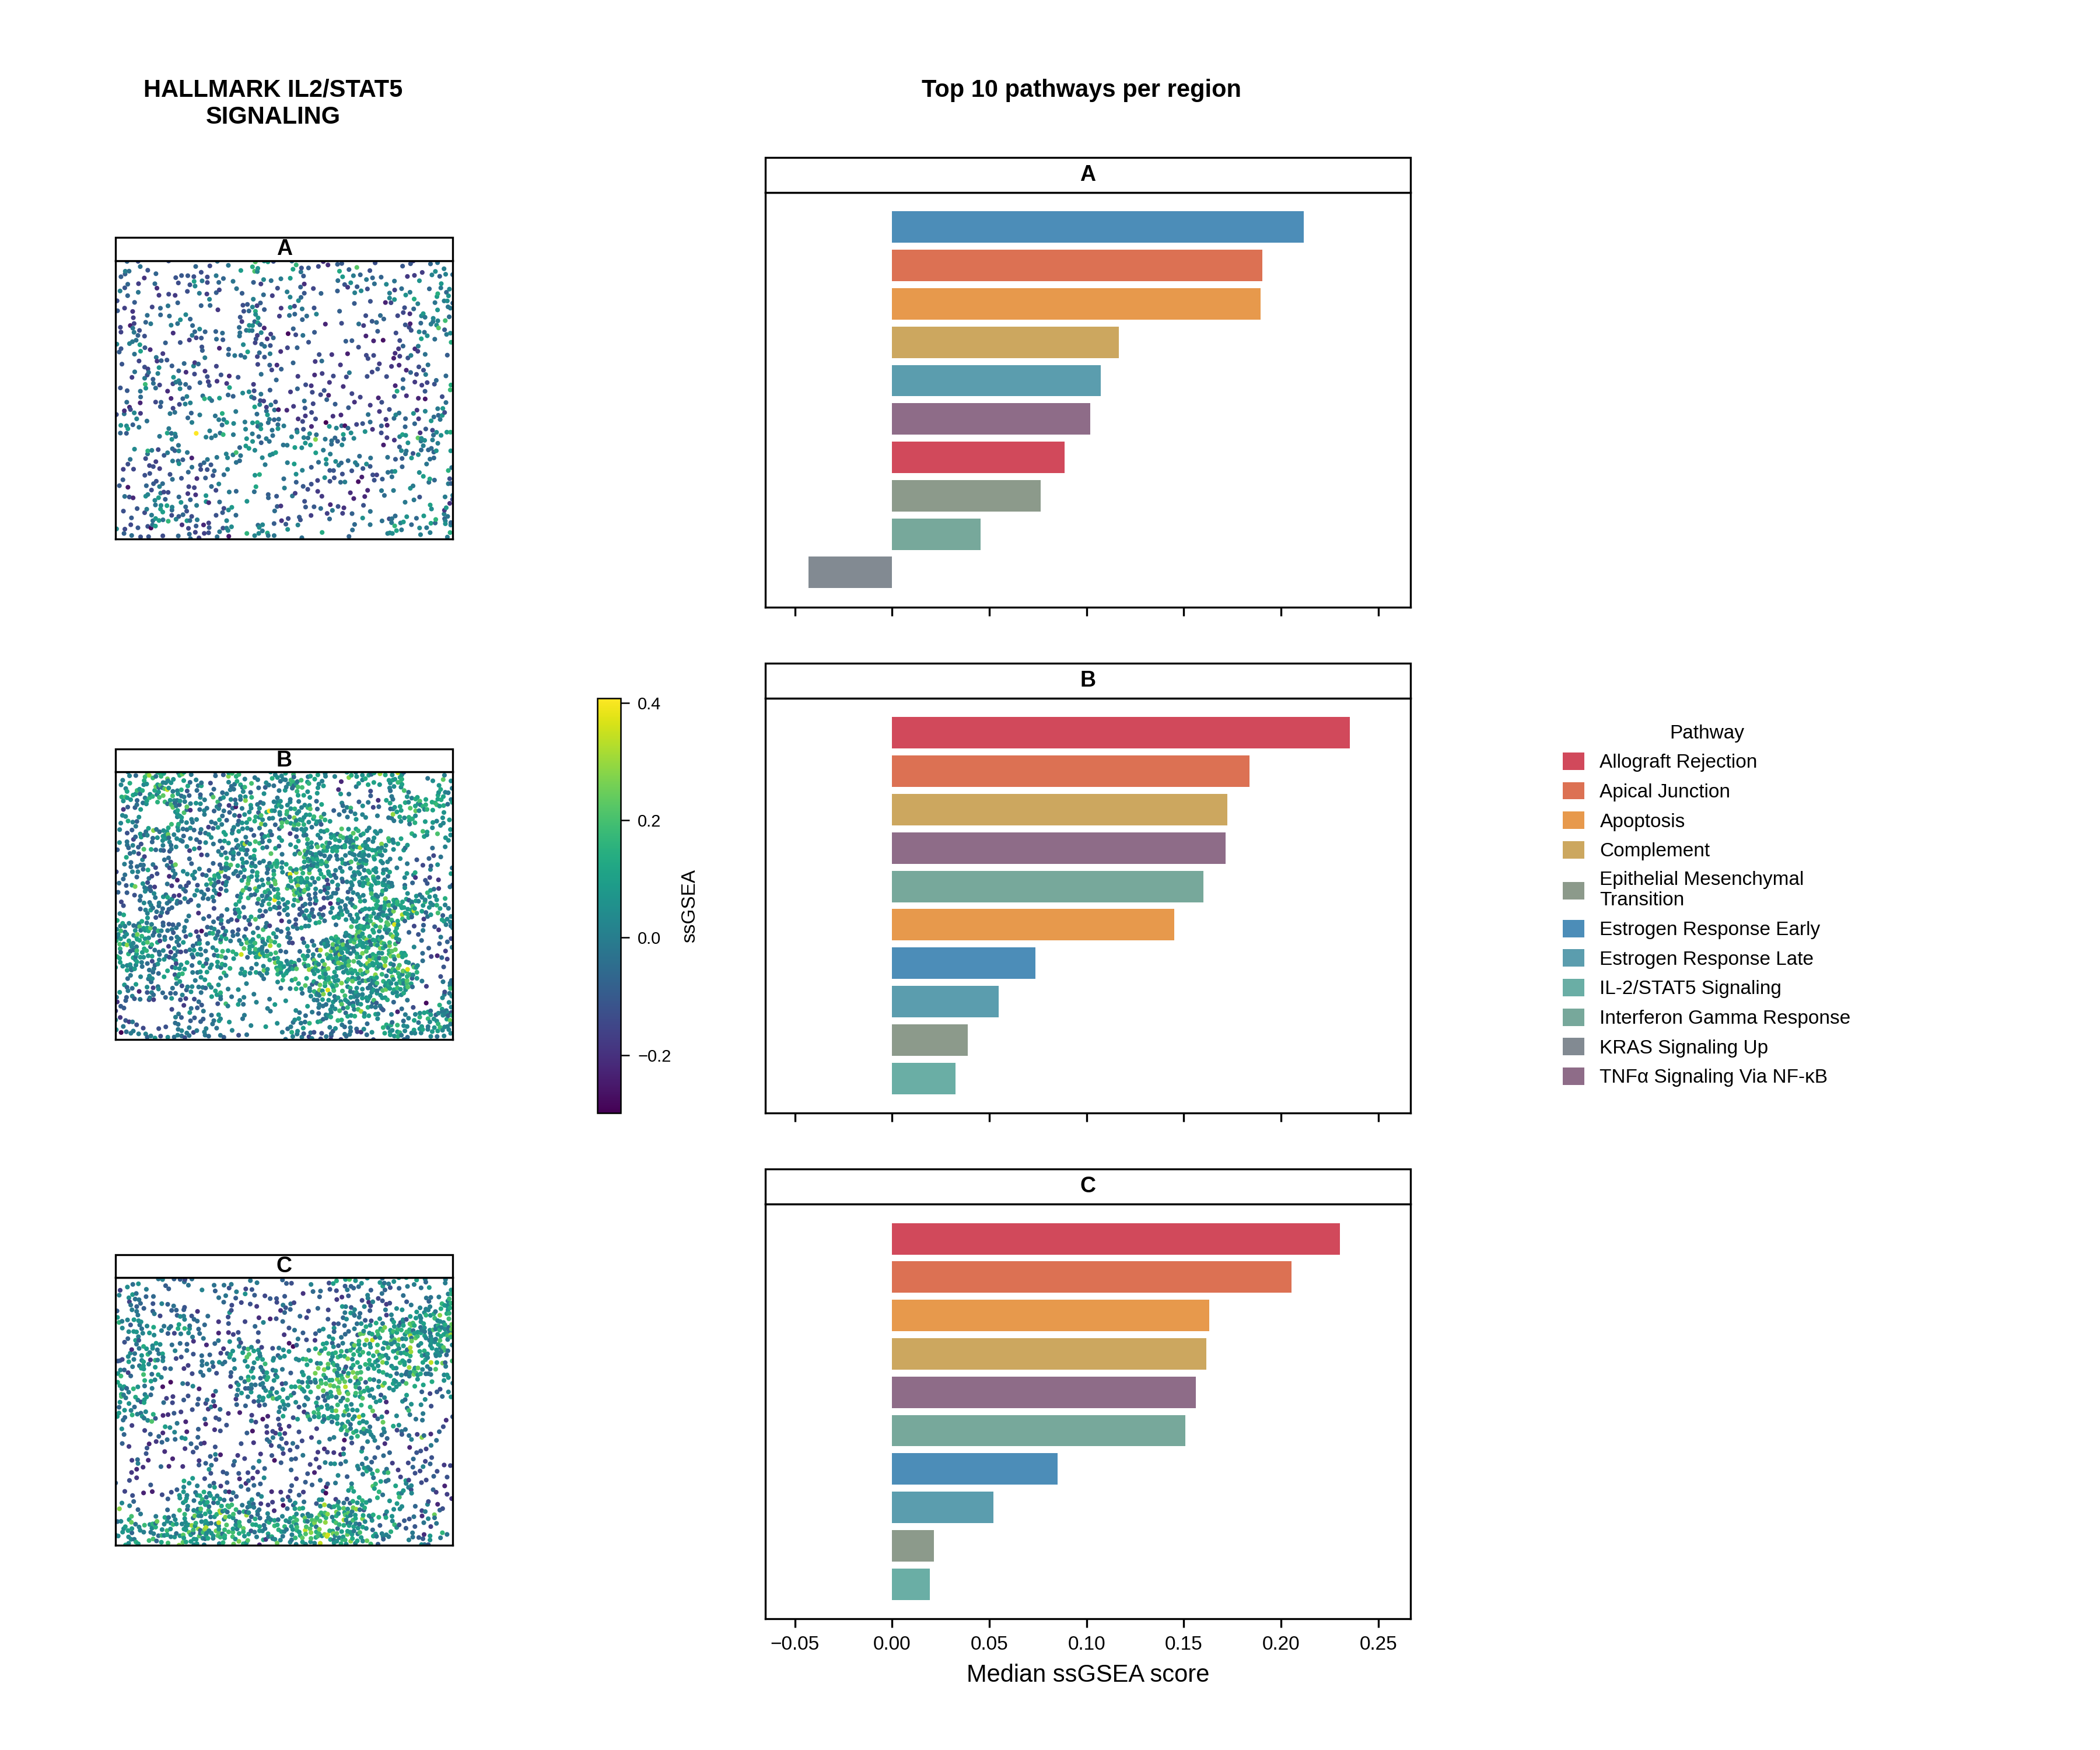

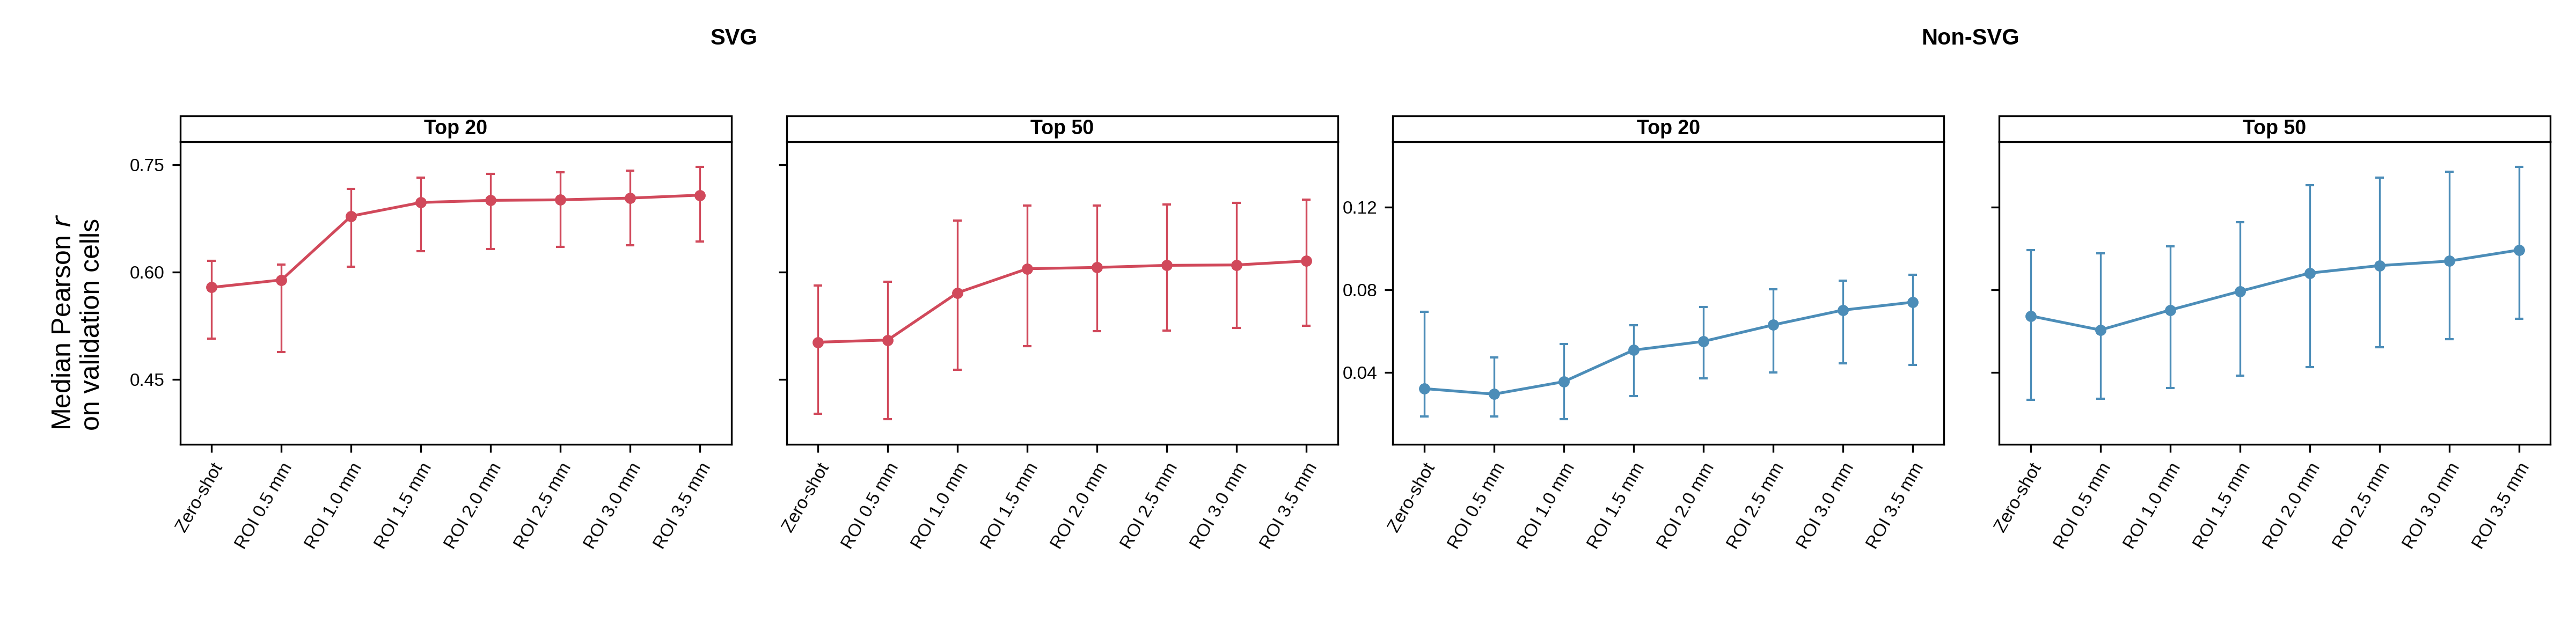

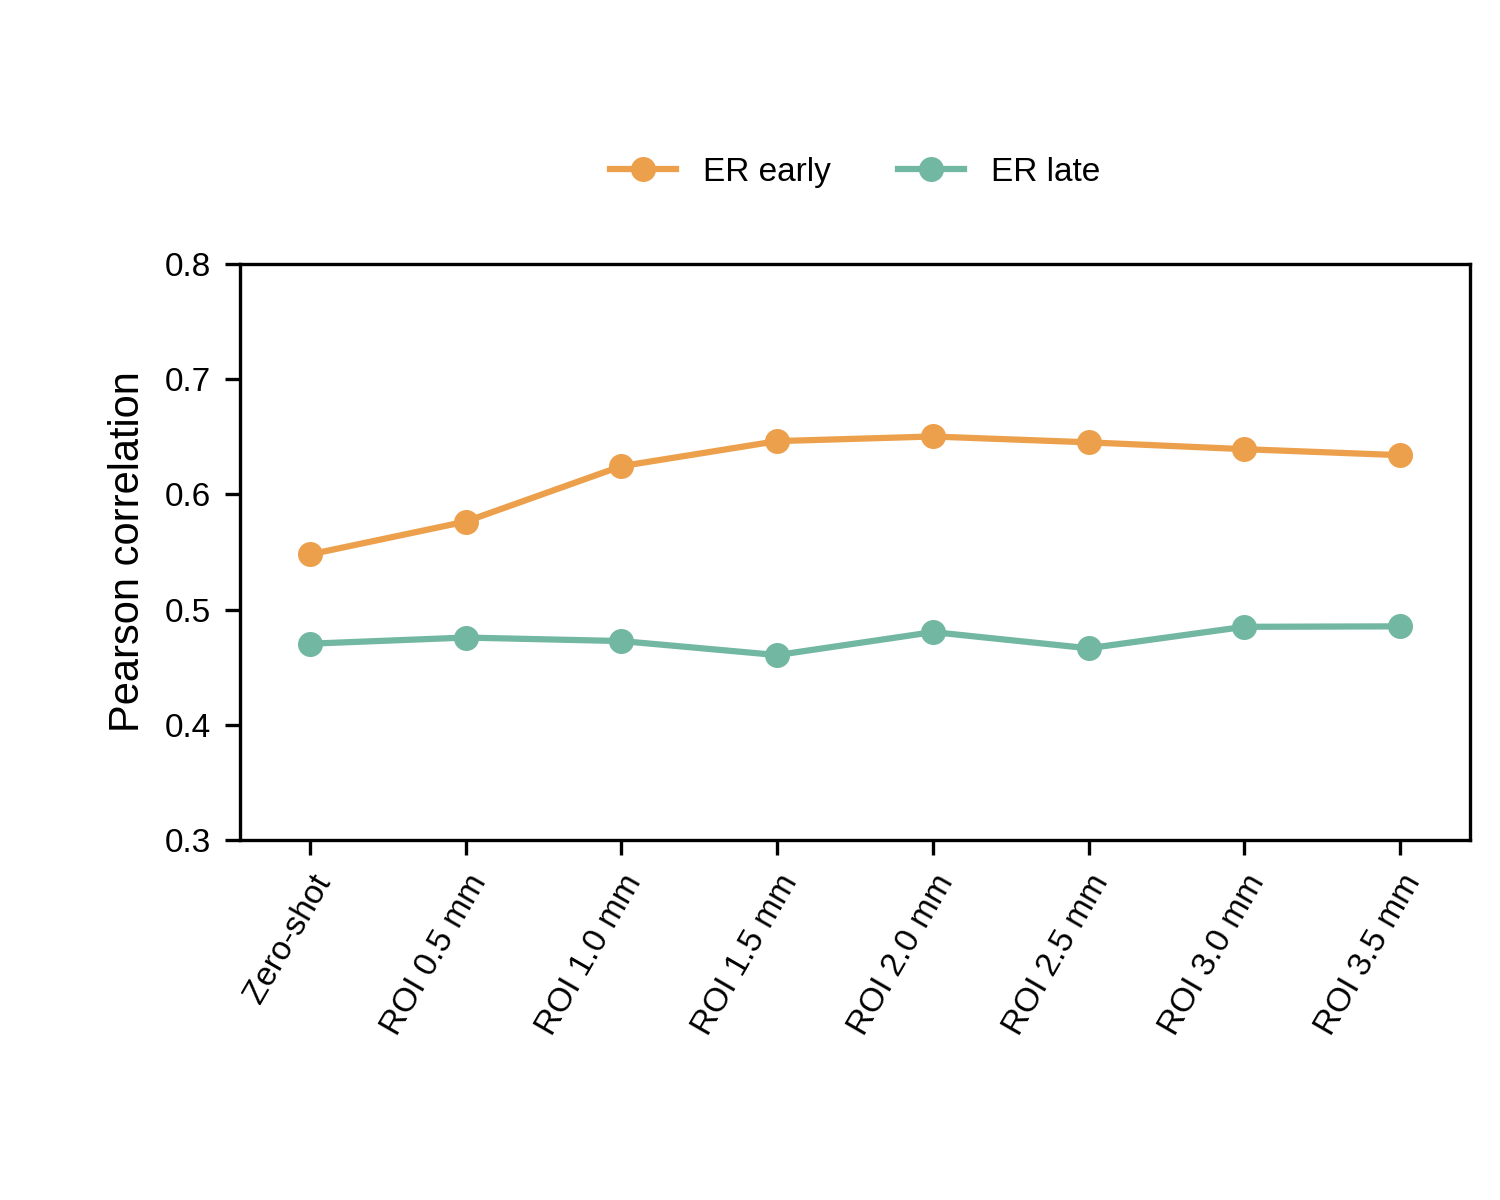

In [3]:
map_data = pd.read_csv(CONFIG["4a_map"])
pathway_data = (
    pd.read_csv(CONFIG["4a_pathways"])
    .rename(columns={"mean_score": "median_score"})
)
figure4b_data = pd.read_csv(CONFIG["4b"])
figure4c_data = pd.read_csv(CONFIG["4c"])

required_columns = (
    (map_data, ["x", "y", "score", "row_id", "region", "x_min", "x_max", "y_min", "y_max"], "Figure 4a map"),
    (pathway_data, ["region", "pathway", "median_score", "n_cells"], "Figure 4a pathways"),
    (
        figure4b_data,
        [
            "Run", "Gene", "ROI size (mm)", "ROI area (% of slide)",
            "Top 20 SVG", "Top 50 SVG", "Top 20 non-SVG", "Top 50 non-SVG",
            "Pearson r on validation cells",
        ],
        "Figure 4b",
    ),
    (figure4c_data, ["pathway", "n", "pearson_r", "spearman_rho", "method"], "Figure 4c"),
)
for frame, columns, label in required_columns:
    require_columns(frame, columns, label)

label_checks = (
    ("Figure 4a map regions", map_data["region"], REGION_ORDER),
    ("Figure 4a pathway regions", pathway_data["region"], REGION_ORDER),
    ("Figure 4b runs", figure4b_data["Run"], RUN_ORDER),
    ("Figure 4c methods", figure4c_data["method"], METHOD_ORDER),
)
for label, observed, expected in label_checks:
    if set(observed) != set(expected):
        raise ValueError(f"{label}: expected {list(expected)}, found {sorted(set(observed))}")

display_figure(plot_figure4a(map_data, pathway_data))
display_figure(plot_figure4b(figure4b_data))
display_figure(plot_figure4c(figure4c_data))